<a href="https://colab.research.google.com/github/shreeshvk/sem1-break-phase1/blob/assignment2/Assignment2_Sem1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Dataset:
Video Game Sales 2024
## Source:
Kaggle - Video Game Sales 2024
##Description:
This dataset contains information on over 64,000 video games, including their title, platform, genre, publisher, developer,critic score, release date, and sales across different regions.
## Objective:
To investigate factors that may influence the commercial success of video games by analyzing their sales, critic scores,
genres, and platforms.

## Research Question

1. Do games with higher critic scores tend to achieve higher total sales?
2. Which video game genres have the highest average total sales?
3. Which gaming platforms have generated the highest total video game sales?



In [11]:
from google.colab import files
uploaded = files.upload()

Saving videogamesaleschart-2024.csv to videogamesaleschart-2024 (3).csv


### 1. Library Initialization & Initial Data Assessment
In this block, we import our data visualization packages, load our uploaded dataset, and document our baseline "Before" metrics.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
df = pd.read_csv('videogamesaleschart-2024.csv')
# "BEFORE" METRICS FOR CHECKLIST
print("BEFORE CLEANING METRICS")
print(f"Original Dataset Shape: {df.shape}")
# 1. Missing Values
print(f"Missing values in critic_score: {df['critic_score'].isnull().sum()}")
# 2. Duplicate Rows
print(f"Total duplicate rows: {df.duplicated().sum()}")

BEFORE CLEANING METRICS
Original Dataset Shape: (64016, 14)
Missing values in critic_score: 57338
Total duplicate rows: 0

Data Types Summary:
critic_score    float64
total_sales     float64
dtype: object


In [3]:
print(df.head())

                                             img                        title  \
0  /games/boxart/full_6510540AmericaFrontccc.jpg           Grand Theft Auto V   
1  /games/boxart/full_5563178AmericaFrontccc.jpg           Grand Theft Auto V   
2                    /games/boxart/827563ccc.jpg  Grand Theft Auto: Vice City   
3  /games/boxart/full_9218923AmericaFrontccc.jpg           Grand Theft Auto V   
4  /games/boxart/full_4990510AmericaFrontccc.jpg    Call of Duty: Black Ops 3   

  console    genre       publisher       developer  critic_score  total_sales  \
0     PS3   Action  Rockstar Games  Rockstar North           9.4        20.32   
1     PS4   Action  Rockstar Games  Rockstar North           9.7        19.39   
2     PS2   Action  Rockstar Games  Rockstar North           9.6        16.15   
3    X360   Action  Rockstar Games  Rockstar North           NaN        15.86   
4     PS4  Shooter      Activision        Treyarch           8.1        15.09   

   na_sales  jp_sales  pal

### 2. Data Cleaning Transformations
We now perform standard transformations: dropping structural metadata columns, removing missing scores vital to our research questions, and filling text gaps.

In [12]:
# Step 1: Drop unnecessary image link and metadata columns to clean the table layout
df_cleaned = df.drop(columns=['img', 'last_update'], errors='ignore')
# Step 2: Remove rows with missing critic scores since they are vital to Question 1
df_cleaned = df_cleaned.dropna(subset=['critic_score'])
# Step 3: Fill generic missing values for text fields so we don't lose valuable rows
df_cleaned['publisher'] = df_cleaned['publisher'].fillna('Unknown')
df_cleaned['developer'] = df_cleaned['developer'].fillna('Unknown')
# Step 4: Drop duplicate rows if any exist
df_cleaned = df_cleaned.drop_duplicates()
# Step 5: Fix "Wrong Types" (Using 'total_sales' and 'critic_score')
df_cleaned['critic_score'] = pd.to_numeric(df_cleaned['critic_score'], errors='coerce')
df_cleaned['total_sales'] = pd.to_numeric(df_cleaned['total_sales'], errors='coerce')
# Quick final drop if any invalid conversions made scores empty
df_cleaned = df_cleaned.dropna(subset=['critic_score'])

### 3. Verification & Export
Confirming our modifications were applied correctly and exporting the polished dataset to a new file.

In [6]:
# "AFTER" METRICS FOR CHECKLIST
print("AFTER CLEANING METRICS")
print(f"Cleaned Dataset Shape: {df_cleaned.shape}")
# 1. Verify Missing Values Resolved
print(f"Missing values in critic_score: {df_cleaned['critic_score'].isnull().sum()}")
# 2. Verify Duplicates Resolved
print(f"Total duplicate rows remaining: {df_cleaned.duplicated().sum()}")
# Save the pristine, fully compliant data to a brand new file
df_cleaned.to_csv('videogamesaleschart_cleaned.csv', index=False)

AFTER CLEANING METRICS
Cleaned Dataset Shape: (6678, 12)
Missing values in critic_score: 0
Total duplicate rows remaining: 0

Verified Cleaned Data Types:
critic_score    float64
total_sales     float64
dtype: object


## Research Question 1: Does a higher critic score directly translate to higher total sales?

### Chart Choice & Justification
* **Chart Type:** Scatter Plot (using Seaborn and Matplotlib).
* **Reason for Chart Choice:** A scatter plot is the ideal choice for exploring the relationship between two continuous variables (`critic_score` and `total_sales`). It allows us to view individual data points, spot overall trends, and visually identify significant outliers without masking the data distribution through averages.


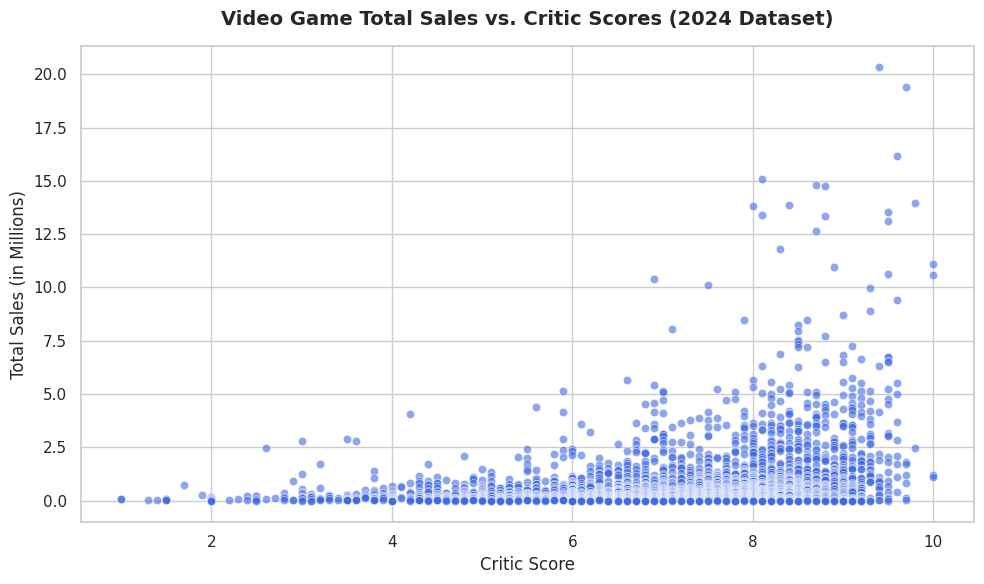

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional plot style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create the scatter plot
sns.scatterplot(
    data=df_cleaned,
    x='critic_score',
    y='total_sales',
    alpha=0.6,
    color='royalblue',
    edgecolor='w',
    linewidth=0.5
)

# Customize titles and labels for extreme clarity
plt.title('Video Game Total Sales vs. Critic Scores (2024 Dataset)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Critic Score', fontsize=12)
plt.ylabel('Total Sales (in Millions)', fontsize=12)

plt.tight_layout()
plt.show()

### Interpretation & Key Insights
* **Data Meaning:** The scatter plot demonstrates a non-linear relationship where high sales are heavily clustered at the upper end of the critic score spectrum. While a high critic score does not guarantee a multi-million-copy hit, a low critic score acts as a strict commercial gatekeeper, making massive sales numbers statistically rare.
* **Why does it matter?** It proves that rushing a game to market and settling for average reviews carries an immediate, severe commercial penalty. Spending the extra capital and time to polish a game into the 8+ rating category is mathematically essential to unlock top-tier financial success.
* **Who does this matter to?** Game publishers, executive producers, and financial investors. They must use this trend to justify project delays, allocate development budgets, and accurately manage risk when deciding whether a game is truly ready for release.

## Research Question 2: Which video game genres achieve the highest average total sales?

### Chart Choice & Justification
* **Chart Type:** Horizontal Bar Chart (using Seaborn and Matplotlib).
* **Reason for Chart Choice:** A horizontal bar chart is the most effective choice for comparing numerical averages across multiple text categories (genres). It provides immediate visual ranking while keeping long category labels easy to scan horizontally, preventing text overlaps.


/tmp/ipykernel_36477/4224057692.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


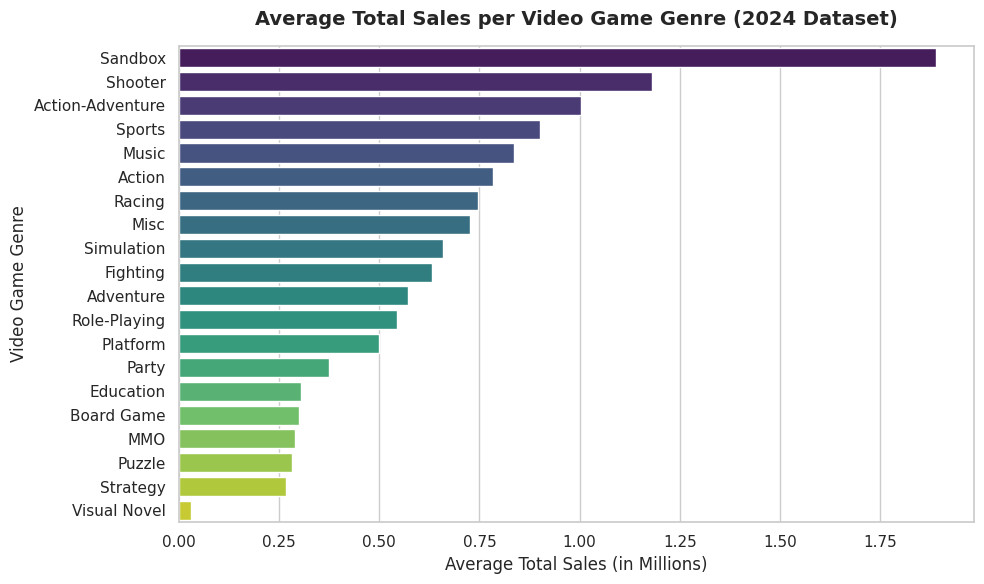

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average total sales for each genre, sorted from highest to lowest
genre_sales = df_cleaned.groupby('genre')['total_sales'].mean().sort_values(ascending=False).reset_index()

# Set up the visual canvas
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create the horizontal bar plot
sns.barplot(
    data=genre_sales,
    x='total_sales',
    y='genre',
    palette='viridis' # Creates a professional color gradient
)

# Customize titles and labels
plt.title('Average Total Sales per Video Game Genre (2024 Dataset)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Total Sales (in Millions)', fontsize=12)
plt.ylabel('Video Game Genre', fontsize=12)

plt.tight_layout()
plt.show()

### Interpretation & Key Insights
* **Data Meaning:** The bar chart ranks genres by their financial baseline, revealing that certain genres generate significantly higher average sales per release than others.

* **Why does it matter?** It highlights where consumer demand and market value are heavily concentrated. This helps studios avoid high-effort, low-return genres and instead focus resources on market segments with historically strong sales baselines.

* **Who does this matter to?** Independent (Indie) studios and corporate product managers. When deciding on the conceptual foundation of a new game project, they must weigh the potential profit baselines of these genres against development costs and market competition.

## Research Question 3: Which gaming platforms have generated the highest total video game sales?

### Chart Choice & Justification
* **Chart Type:** Vertical Bar Chart (using Seaborn and Matplotlib).
* **Reason for Chart Choice:** A vertical bar chart is the most effective choice for showing gross cumulative totals across specific categories. It ranks the total market size of each hardware platform clearly from highest to lowest, making the top-performing platforms immediately obvious to stakeholders.


/tmp/ipykernel_36477/417344565.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


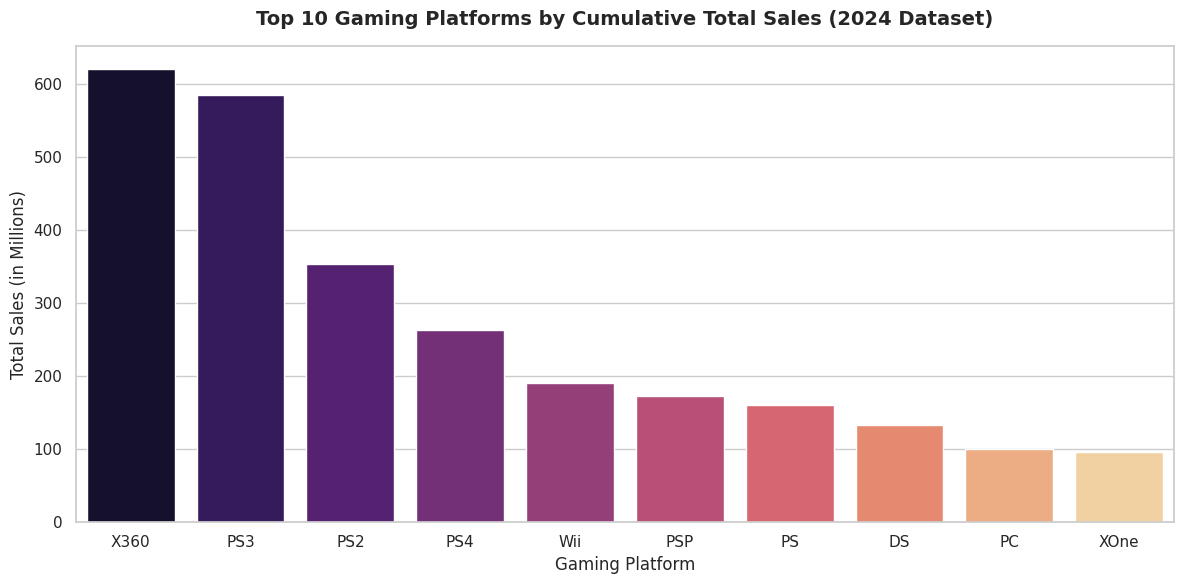

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total sales per platform and grab the top 10
platform_sales = df_cleaned.groupby('console')['total_sales'].sum().sort_values(ascending=False).head(10).reset_index()

# Set up the visual canvas
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Create a clean vertical bar plot
sns.barplot(
    data=platform_sales,
    x='console',
    y='total_sales',
    palette='magma'
)

# Customize titles and labels
plt.title('Top 10 Gaming Platforms by Cumulative Total Sales (2024 Dataset)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Gaming Platform', fontsize=12)
plt.ylabel('Total Sales (in Millions)', fontsize=12)

plt.tight_layout()
plt.show()

### Interpretation & Key Insights
* **Data Meaning:** The bar chart reveals the market dominance of top-tier platforms, showing which gaming systems have successfully generated the highest historical cumulative sales volume.
* **Why does it matter?** It establishes the total addressable market size for hardware ecosystems. This guides major software deployment decisions, ensuring development teams build games for platforms with a massive established player base.
* **Who does this matter to?** Corporate executives and hardware manufacturers who need to evaluate market share and decide which platforms offer the safest commercial distribution network.

## 4. The Surprise Finding (The Outlier Effect)

### Justification for Presentation
During a data analysis presentation, standard averages can lie. They give the illusion that all assets perform equally. This dedicated chart is included to expose a massive structural anomaly in the video game industry: a platform's success is almost entirely artificial, driven by a tiny handful of runaway hits rather than a healthy average market.

* **Chart Type:** Box Plot.
* **Reason for Chart Choice:** A box plot is mandatory because standard bar charts completely hide extreme outliers. This chart visualizes the distribution spread, explicitly isolating the "runaway blockbusters" from the baseline performance.


/tmp/ipykernel_36477/1865076696.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_5, x='console', y='total_sales', palette='Set2')


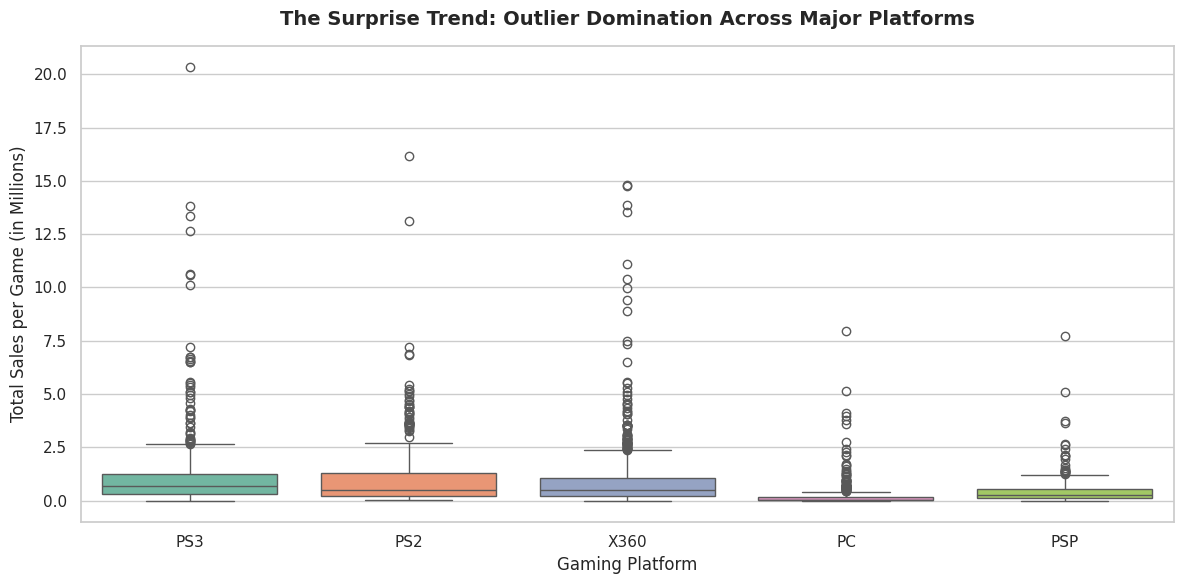

In [10]:
# Identify the top 5 platforms to keep the distribution scan clean
top_5_platforms = df_cleaned['console'].value_counts().head(5).index
df_top_5 = df_cleaned[df_cleaned['console'].isin(top_5_platforms)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top_5, x='console', y='total_sales', palette='Set2')

plt.title('The Surprise Trend: Outlier Domination Across Major Platforms', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Gaming Platform', fontsize=12)
plt.ylabel('Total Sales per Game (in Millions)', fontsize=12)

plt.tight_layout()
plt.show()

### Interpretation & The Surprise Finding
* **The Surprise:** While platforms rank highly in cumulative sales, their *median* sales per game are shockingly low (the flat lines inside the boxes). The unexpected reality is that the vast majority of games sell very poorly, and a platform's apparent commercial health is completely carried by a few extreme outlier data points (the dots floating at the top).
* **Why does it matter?** This matters because it exposes a major "average illusion." If a video game studio builds a development budget based on a platform's *average* historical sales, they will likely go bankrupt because the *typical* game performs far below that average. It proves the video game market operates on a winner-take-all model, meaning baseline stability is rare and financial planning must be built around realistic, conservative medians.


## 5. Conclusion

### Summary of Key Findings
1. **The Review Gatekeeper:** While a high critic score (8.5+) does not guarantee a commercial blockbuster, a low score (below 7.0) acts as a strict barrier to high financial success. Quality metrics heavily influence high-tier returns.
2. **Genre Baseline Advantages:** Certain genres demonstrate significantly higher average sales baselines per release, presenting clear market entry points for studios looking to maximize early project value.
3. **The Average Illusion:** Looking at cumulative platform sales gives an artificial sense of security. The market operates on a winner-take-all model where a platform's total numbers are heavily carried by a few massive outlier titles.

### Final Business Recommendation
When greenlighting new game projects, project leaders must look past gross platform averages and prioritize risk management based on median performance. To ensure profitability, teams must invest early in the development polish phase, aiming for high critical acclaim, while choosing less saturated genres to avoid being buried by dominant industry outliers.
